In [32]:
# import packages and load data in
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

year_and_month = ['202511','202512','202601', '202602', '202603', '202604', '202605']
CRMLSSold_data = pd.DataFrame()

for year_month in year_and_month:
    # Load the data for each year and month
    data = pd.read_csv(f'data/CRMLSSold{year_month}.csv')
    # Append the data to the main DataFrame
    CRMLSSold_data = pd.concat([CRMLSSold_data, data], ignore_index=True)

#  PropertyType filter 
CRMLSSold_data = CRMLSSold_data[
    (CRMLSSold_data['PropertyType'] == 'Residential') &
    (CRMLSSold_data['PropertySubType'] == 'SingleFamilyResidence')
]

/var/folders/jc/zlyx5cfj47b4kf9kgt678kkc0000gn/T/ipykernel_79553/1437279264.py:12: DtypeWarning: Columns (0: WaterfrontYN, 1: PostalCode) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(f'data/CRMLSSold{year_month}.csv')


In [33]:
# Features decided in 01_exploration.ipynb

# Target
target = ['ClosePrice']  # log-transform for modeling

# Core size/structure features
size_features = [
    'LivingArea',           # log-transform; strongest predictor
    'BedroomsTotal',
    'BathroomsTotalInteger',
    'YearBuilt',            # or bin into decades / home age
    'GarageSpaces',         # ~13% missing; impute
    'LotSizeSquareFeet'    # weak standalone signal; include anyway

]

# Location features
location_features = [
    'Latitude',
    'Longitude',
    'CountyOrParish',       # alternative categorical encoding
]

# Amenity flags
amenity_features = [
    'PoolPrivateYN',
    'ViewYN',
    'FireplaceYN',
    # 'NewConstructionYN',  # direction counterintuitive; investigate before using
    # 'WaterfrontYN',       # excluded: only 86 non-missing rows
]

features = size_features + location_features + amenity_features
print(f"Total features: {len(features)}")
print(features)

Total features: 12
['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'YearBuilt', 'GarageSpaces', 'LotSizeSquareFeet', 'Latitude', 'Longitude', 'CountyOrParish', 'PoolPrivateYN', 'ViewYN', 'FireplaceYN']


In [34]:
# table of missing percentage of each feature
all_cols = target + features
missing = CRMLSSold_data[all_cols].isna().mean().mul(100).round(2).sort_values(ascending=False)
display(missing.rename('% Missing').to_frame())

,% Missing
ViewYN,8.69
PoolPrivateYN,7.81
GarageSpaces,3.85
LotSizeSquareFeet,1.72
FireplaceYN,0.09
YearBuilt,0.06
LivingArea,0.05
Latitude,0.01
Longitude,0.01
ClosePrice,0.00


In [35]:
# Sanity filters and 1st/99th percentile boundary removal

n_start = len(CRMLSSold_data)
print(f"Start: {n_start:,}")

#  Hard filters: physically impossible or clearly bad values
n = len(CRMLSSold_data)
CRMLSSold_data = CRMLSSold_data[
    (CRMLSSold_data["ClosePrice"] > 0) &
    (CRMLSSold_data["LivingArea"] > 0) &
    (CRMLSSold_data["BedroomsTotal"] > 0) &
    (CRMLSSold_data["YearBuilt"].isna() | CRMLSSold_data["YearBuilt"].between(1800, 2026))
]
print(f"After hard filters:      {len(CRMLSSold_data):,}  (-{n - len(CRMLSSold_data):,})")

#  1st/99th percentile removal
# 99th percentile removal only for bedrooms and bathrooms due to the few outliers runing generalization
# Compute all bounds first on the same snapshot, then filter once.
price_low,  price_high  = CRMLSSold_data["ClosePrice"].quantile([0.01, 0.99])
living_low, living_high = CRMLSSold_data["LivingArea"].quantile([0.01, 0.99])
lot_low,    lot_high    = CRMLSSold_data["LotSizeSquareFeet"].quantile([0.01, 0.99])
bed_high                = CRMLSSold_data["BedroomsTotal"].quantile(0.99)
bath_high               = CRMLSSold_data["BathroomsTotalInteger"].quantile(0.99)

n = len(CRMLSSold_data)
CRMLSSold_data = CRMLSSold_data[
    CRMLSSold_data["ClosePrice"].between(price_low, price_high) &
    CRMLSSold_data["LivingArea"].between(living_low, living_high) &
    (CRMLSSold_data["LotSizeSquareFeet"].isna() | CRMLSSold_data["LotSizeSquareFeet"].between(lot_low, lot_high)) &
    (CRMLSSold_data["BedroomsTotal"] <= bed_high) &
    (CRMLSSold_data["BathroomsTotalInteger"].isna() | (CRMLSSold_data["BathroomsTotalInteger"] <= bath_high))
]
print(f"After percentile filter: {len(CRMLSSold_data):,}  (-{n - len(CRMLSSold_data):,})")

n_end = len(CRMLSSold_data)
print(f"{n_start:,}  ->  {n_end:,}  (-{n_start - n_end:,}, {(n_start - n_end) / n_start:.1%})")
print(f"ClosePrice:            [{price_low:,.0f}, {price_high:,.0f}]")
print(f"LivingArea:            [{living_low:,.0f}, {living_high:,.0f}]")
print(f"LotSizeSquareFeet:     [{lot_low:,.0f}, {lot_high:,.0f}]")
print(f"BedroomsTotal:         <= {bed_high:.0f}")
print(f"BathroomsTotalInteger: <= {bath_high:.0f}")
CRMLSSold_data = CRMLSSold_data.reset_index(drop=True)

Start: 71,466
After hard filters:      71,383  (-83)
After percentile filter: 67,340  (-4,043)
71,466  ->  67,340  (-4,126, 5.8%)
ClosePrice:            [230,000, 6,450,000]
LivingArea:            [743, 5,686]
LotSizeSquareFeet:     [1,724, 306,227]
BedroomsTotal:         <= 6
BathroomsTotalInteger: <= 6


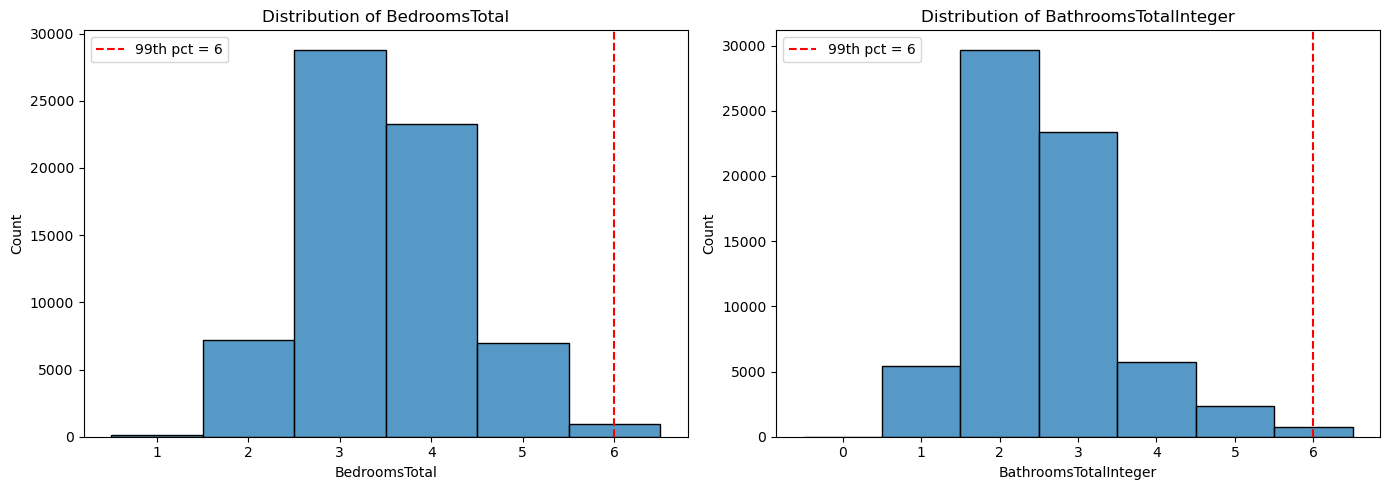

BedroomsTotal       99th pct: 6,  max: 6
BathroomsTotalInteger 99th pct: 6,  max: 6


In [36]:
# Distribution of BedroomsTotal and BathroomsTotalInteger after filtering
# to check if extreme values are removed after filtered the extreme skewed variables
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ['BedroomsTotal', 'BathroomsTotalInteger']):
    data = CRMLSSold_data[col].dropna()
    p99 = data.quantile(0.99)
    sns.histplot(data, discrete=True, ax=ax)
    ax.axvline(p99, color='red', linestyle='--', label=f'99th pct = {p99:.0f}')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.legend()

plt.tight_layout()
plt.show()

print(f"BedroomsTotal       99th pct: {CRMLSSold_data['BedroomsTotal'].quantile(0.99):.0f},  max: {CRMLSSold_data['BedroomsTotal'].max():.0f}")
print(f"BathroomsTotalInteger 99th pct: {CRMLSSold_data['BathroomsTotalInteger'].quantile(0.99):.0f},  max: {CRMLSSold_data['BathroomsTotalInteger'].max():.0f}")

In [37]:
# updated missing percentage table after filtering
all_cols = target + features
missing = CRMLSSold_data[all_cols].isna().mean().mul(100).round(2).sort_values(ascending=False)
display(missing.rename('% Missing').to_frame())

,% Missing
ViewYN,8.99
PoolPrivateYN,7.62
GarageSpaces,3.64
LotSizeSquareFeet,1.77
FireplaceYN,0.08
YearBuilt,0.04
Latitude,0.01
Longitude,0.01
ClosePrice,0.00
LivingArea,0.00


In [38]:
# Impute amenity flags with 'Unknown' if missing as it could be a signal(only 10% of data)
# The missing values in these columns differentiate in median compared to 
# the non-missing values so this can indicate a signal or pattern that could be useful for modeling.
for col in ['ViewYN', 'PoolPrivateYN', 'FireplaceYN']:
    CRMLSSold_data[col] = CRMLSSold_data[col].fillna('Unknown')



# Drop rows where LotSizeSquareFeet is null and GarageSpaces is null (~5%)
# less than 5% so we are not losing a lot of data from removing these missing rows
n = len(CRMLSSold_data)
CRMLSSold_data = CRMLSSold_data.dropna(subset=all_cols)
print(f"After dropping null LotSizeSquareFeet: {len(CRMLSSold_data):,}  (-{n - len(CRMLSSold_data):,})")
# % difference 
print(f"Percentage of rows dropped: {(n - len(CRMLSSold_data)) / n:.2%}")

# Verify no remaining nulls in used columns
display(CRMLSSold_data[all_cols].isna().mean().mul(100).round(2).sort_values(ascending=False).rename('% Missing').to_frame())

# 

After dropping null LotSizeSquareFeet: 63,684  (-3,656)
Percentage of rows dropped: 5.43%


,% Missing
ClosePrice,0.0
LivingArea,0.0
BedroomsTotal,0.0
BathroomsTotalInteger,0.0
YearBuilt,0.0
GarageSpaces,0.0
LotSizeSquareFeet,0.0
Latitude,0.0
Longitude,0.0
CountyOrParish,0.0


In [39]:
from sklearn.preprocessing import StandardScaler
"""
Log transforms 

We log-transform to aid normality and skewness for our base linear regression model
non-linear variables still will work even with log close price as
it just changes scale of target variable
close price has strong correlation with living area so log-transform to make the relationship more linear
"""
CRMLSSold_data['LogClosePrice'] = np.log(CRMLSSold_data['ClosePrice'])
CRMLSSold_data['LogLivingArea'] = np.log(CRMLSSold_data['LivingArea'])

#  Categorical encoding 
# make each unique value into new column that is 0 or 1 so model can use feature
cat_cols = ['CountyOrParish', 'ViewYN', 'PoolPrivateYN', 'FireplaceYN']
CRMLSSold_data = pd.get_dummies(CRMLSSold_data, columns=cat_cols, dtype=int)

#  Feature matrix 
log_features = ['LogLivingArea', 'BedroomsTotal', 'BathroomsTotalInteger',
                'YearBuilt', 'GarageSpaces', 'LotSizeSquareFeet',
                'Latitude', 'Longitude']
encoded_cols = [c for c in CRMLSSold_data.columns
                if c.startswith(('CountyOrParish_', 'ViewYN_', 'PoolPrivateYN_', 'FireplaceYN_'))]
feature_cols = log_features + encoded_cols

#  Train/test split by time 
# Test set: May 2026 (fixed). Train set: all preceding months in the dataset.
# about a 80/20 split of our data 
CRMLSSold_data['CloseDate'] = pd.to_datetime(CRMLSSold_data['CloseDate'])
CRMLSSold_data['CloseMonth'] = CRMLSSold_data['CloseDate'].dt.to_period('M')

# freq='M' so we can compare the month and year correctly 
TEST_MONTH = pd.Period('2026-05', freq='M')
train = CRMLSSold_data[CRMLSSold_data['CloseMonth'] < TEST_MONTH].copy()
test  = CRMLSSold_data[CRMLSSold_data['CloseMonth'] == TEST_MONTH].copy()

# Normalization to compare features on the same scale
# Fit scaler on train only, transform both — prevents leakage from test set
scale_cols = ['LogLivingArea', 'BedroomsTotal', 'BathroomsTotalInteger',
              'YearBuilt', 'GarageSpaces', 'LotSizeSquareFeet', 'Latitude', 'Longitude']
scaler = StandardScaler()
train[scale_cols] = scaler.fit_transform(train[scale_cols])
test[scale_cols]  = scaler.transform(test[scale_cols])

X_train = train[feature_cols]
y_train = train['LogClosePrice']
X_test  = test[feature_cols]
y_test  = test['LogClosePrice']


print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"Features: {len(feature_cols)}")

X_train: (52958, 76)  |  X_test: (10726, 76)
Features: 76


In [40]:
# sample of the training data
display(X_train.head())

,LogLivingArea,BedroomsTotal,BathroomsTotalInteger,YearBuilt,GarageSpaces,LotSizeSquareFeet,Latitude,Longitude,CountyOrParish_Alameda,CountyOrParish_Amador,...,CountyOrParish_Yuba,ViewYN_False,ViewYN_True,ViewYN_Unknown,PoolPrivateYN_False,PoolPrivateYN_True,PoolPrivateYN_Unknown,FireplaceYN_False,FireplaceYN_True,FireplaceYN_Unknown
0,-1.521682,-0.553934,-0.603317,-0.589763,0.000501,-0.291610,-0.601611,0.159252,0,0,...,0,1,0,0,1,0,0,1,0,0
1,-1.275641,-0.553934,-1.663384,-1.032475,0.000501,0.182343,1.404072,-0.914256,0,0,...,0,1,0,0,0,0,1,0,1,0
2,-0.338989,0.590276,0.456751,0.037413,0.000501,-0.314818,-1.223268,0.412936,0,0,...,0,1,0,0,1,0,0,0,1,0
3,1.150398,1.734486,0.456751,0.849052,0.428579,-0.315878,-1.217236,0.423827,0,0,...,0,1,0,0,1,0,0,0,1,0
4,-0.171194,-0.553934,-0.603317,-0.995582,0.428579,-0.117953,0.448618,-0.580229,0,0,...,0,1,0,0,1,0,0,0,1,0


In [41]:
# save clean csv
CRMLSSold_data.to_csv('data/cleaned_CRMLSSOLD_data.csv', index=False)